In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Obesity_data_final.csv')

# 与 model_final 一致：仅保留三列出行 one-hot，不使用 transport_4（Motorbike 在 transport_4，本管线丢弃该列）
if "transport_4" in df.columns:
    df = df.drop(columns=["transport_4"])
for c in ["transport_1", "transport_2", "transport_3"]:
    if c in df.columns:
        df[c] = df[c].astype(int)

# 与 model_final 一致：数值编码列重命名为短列名；若与原始文本列重名则先删文本列
for col in list(df.columns):
    if str(col).endswith("_enc"):
        continue
    if f"{col}_enc" in df.columns:
        df = df.drop(columns=[col])
enc_rename = {c: c[:-4] for c in df.columns if str(c).endswith("_enc")}
df = df.rename(columns=enc_rename)

# 与 model_final 中 pd.get_dummies(..., prefix="transport") 列名一致
# （Obesity_inputheight：transport_1=Walking, transport_2=Automobile, transport_3=Bike；全 0 表示 Public_Transportation）
_transport_rename = {
    "transport_1": "transport_Walking",
    "transport_2": "transport_Automobile",
    "transport_3": "transport_Bike",
}
df = df.rename(columns={k: v for k, v in _transport_rename.items() if k in df.columns})

# 删除原始 transport 字符串列
if "transport" in df.columns:
    df = df.drop(columns=["transport"])

if "age" in df.columns:
    df["age"] = pd.to_numeric(df["age"], errors="coerce")

print("数据集形状:", df.shape)
print("列名列表:", list(df.columns))
print(df.head())


数据集形状: (2087, 19)
列名列表: ['age', 'height', 'weight', 'transport_Walking', 'transport_Automobile', 'transport_Bike', 'obesity_level', 'gender', 'family_history', 'high_cal_food', 'smoking', 'calorie_monitor', 'snacking', 'alcohol', 'veg_consumption', 'meals_per_day', 'water_intake', 'physical_activity', 'screen_time']
    age  height  weight  transport_Walking  transport_Automobile  \
0  21.0    1.62    64.0                  0                     0   
1  21.0    1.52    56.0                  0                     0   
2  23.0    1.80    77.0                  0                     0   
3  27.0    1.80    87.0                  1                     0   
4  22.0    1.78    89.8                  0                     0   

   transport_Bike        obesity_level  gender  family_history  high_cal_food  \
0               0        Normal_Weight       0               1              0   
1               0        Normal_Weight       0               1              0   
2               0        Norma

obesity_level
Insufficient_Weight    267
Normal_Weight          282
Overweight_Level_I     276
Overweight_Level_II    290
Obesity_Type_I         351
Obesity_Type_II        297
Obesity_Type_III       324
Name: count, dtype: int64


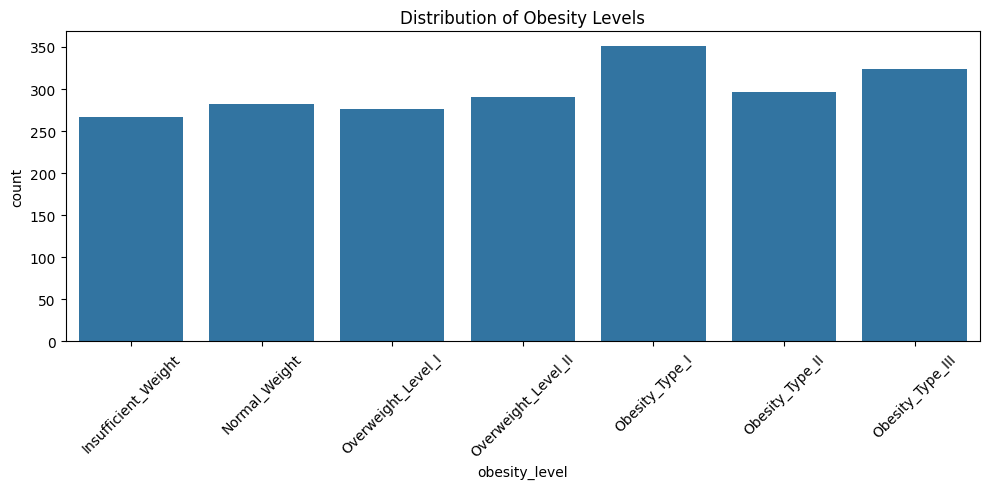

In [13]:
# 与 model_1 一致：肥胖程度顺序（从最瘦到最胖）
severity_order = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III',
]
df['obesity_level'] = pd.Categorical(df['obesity_level'], categories=severity_order, ordered=True)

counts = df['obesity_level'].value_counts(sort=False)
print(counts)
plt.figure(figsize=(10, 5))
sns.barplot(x=counts.index, y=counts.values)
plt.xticks(rotation=45)
plt.title('Distribution of Obesity Levels')
plt.xlabel('obesity_level')
plt.ylabel('count')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 与上一格一致：标签顺序（单独运行本格时需有此定义）
severity_order = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III',
]

# ---------- 特征方案（三选一）：只保留一种赋值，其余用 # 注释 ----------
feature_base = [
    'high_cal_food', 'veg_consumption', 'meals_per_day', 'snacking', 'smoking',
    'water_intake', 'calorie_monitor', 'physical_activity', 'screen_time',
    'alcohol', 'transport_Walking', 'transport_Automobile', 'transport_Bike',
]

# 方案 A：仅生活习惯
# feature_cols = feature_base.copy()

# 方案 B：生活习惯 + 年龄 + 性别（列名为 gender）
# feature_cols = feature_base + ['age', 'gender']

# # 方案 C：生活习惯 + 年龄
feature_cols = feature_base + ['age']

X = df[feature_cols]
le = LabelEncoder()
le.fit(severity_order)
y = le.transform(df['obesity_level'].astype(str))
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2, stratify=y
)
print("Feature columns:", feature_cols)
print("Features shape (raw):", X.shape)
print("Target shape:", y.shape)
print("训练集:", X_train.shape, "测试集:", X_test.shape)

results_rows = []  # 与 model_final.ipynb 一致：汇总各模型测试指标


Feature columns: ['high_cal_food', 'veg_consumption', 'meals_per_day', 'snacking', 'smoking', 'water_intake', 'calorie_monitor', 'physical_activity', 'screen_time', 'alcohol', 'transport_Walking', 'transport_Automobile', 'transport_Bike', 'age', 'gender']
Features shape (raw): (2087, 15)
Target shape: (2087,)
训练集: (1669, 15) 测试集: (418, 15)


In [15]:
from sklearn.preprocessing import StandardScaler

# 与 model_1 一致：对连续变量标准化；树模型仍用未缩放 X
_cont_cols = ['physical_activity', 'screen_time', 'age', 'gender']
numeric_cols = [c for c in _cont_cols if c in X_train.columns]
scaler = StandardScaler()
X_train_lr = X_train.copy()
X_test_lr = X_test.copy()
X_train_lr[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_lr[numeric_cols] = scaler.transform(X_test[numeric_cols])


In [16]:
import warnings
warnings.filterwarnings('ignore')  # 忽略警告信息
import json
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, cross_val_score


def _fmt_params(d):
    return json.dumps(d, ensure_ascii=False, indent=2, default=str)


def _collect_result_row(model_name, best_params_dict, cv_mean_f1, cv_std_f1, y_true, y_pred):
    """与 model_final.ipynb 中 _collect_result 字段一致，便于汇总表。"""
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    prec_m = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec_m = recall_score(y_true, y_pred, average="macro", zero_division=0)
    prec_w = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec_w = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    return {
        "model": model_name,
        "best_params": _fmt_params(best_params_dict),
        "best_cv_macro_f1": round(cv_mean_f1, 5),
        "cv_mean_macro_f1": round(cv_mean_f1, 5),
        "cv_std_macro_f1": round(cv_std_f1, 5),
        "test_accuracy": round(acc, 5),
        "test_macro_f1": round(macro_f1, 5),
        "test_weighted_f1": round(weighted_f1, 5),
        "test_precision_macro": round(prec_m, 5),
        "test_recall_macro": round(rec_m, 5),
        "test_precision_weighted": round(prec_w, 5),
        "test_recall_weighted": round(rec_w, 5),
    }


# 与 final_model/model_1 相同：C / penalty / solver 网格；此处仍用 f1_weighted 选参
scoring_metric = 'f1_weighted'
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'newton-cg'],
}

lrmodel = LogisticRegression(max_iter=2000, random_state=2)
grid_lrmodel = GridSearchCV(lrmodel, param_grid, cv=5, scoring=scoring_metric)
grid_lrmodel.fit(X_train_lr, y_train)
best_lrmodel = grid_lrmodel.best_estimator_
y_pred_model = best_lrmodel.predict(X_test_lr)

cv_scores = cross_val_score(
    best_lrmodel, X_train_lr, y_train, cv=5, scoring="f1_macro", n_jobs=-1
)
cv_mean = float(cv_scores.mean())
cv_std = float(cv_scores.std())

row_lr = _collect_result_row(
    "Logistic Regression (GridSearch)",
    grid_lrmodel.best_params_,
    cv_mean,
    cv_std,
    y_test,
    y_pred_model,
)
results_rows.append(row_lr)
print("逻辑回归 训练完成。测试 Macro F1:", row_lr["test_macro_f1"])
print("Best params:", grid_lrmodel.best_params_)


逻辑回归 训练完成。测试 Macro F1: 0.5317
Best params: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}


In [17]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

scoring_metric = 'f1_weighted'
dt = DecisionTreeClassifier(random_state=2)
param_grid = {
    'max_depth': [12, 15, 18, 20, None],
    'min_samples_split': [2, 3, 4, 5],
    'min_samples_leaf': [1, 2, 3, 4]
}
grid_dt = GridSearchCV(dt, param_grid, cv=5, scoring=scoring_metric)
grid_dt.fit(X_train, y_train)
best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)

cv_scores = cross_val_score(best_dt, X_train, y_train, cv=5, scoring="f1_macro", n_jobs=-1)
cv_mean = float(cv_scores.mean())
cv_std = float(cv_scores.std())

row_dt = _collect_result_row(
    "Decision Tree (GridSearch)",
    grid_dt.best_params_,
    cv_mean,
    cv_std,
    y_test,
    y_pred_dt,
)
results_rows.append(row_dt)
print("决策树 训练完成。测试 Macro F1:", row_dt["test_macro_f1"])
print("Best params:", grid_dt.best_params_)


决策树 训练完成。测试 Macro F1: 0.70199
Best params: {'max_depth': 18, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

scoring_metric = 'f1_weighted'
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
}
rf = RandomForestClassifier(random_state=2)
grid = GridSearchCV(rf, param_grid, cv=5, scoring=scoring_metric, n_jobs=1)
grid.fit(X_train, y_train)
best_rf = grid.best_estimator_
y_pred = best_rf.predict(X_test)

cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring="f1_macro", n_jobs=-1)
cv_mean = float(cv_scores.mean())
cv_std = float(cv_scores.std())

row_rf = _collect_result_row(
    "Random Forest (GridSearch)",
    grid.best_params_,
    cv_mean,
    cv_std,
    y_test,
    y_pred,
)
results_rows.append(row_rf)
print("随机森林 训练完成。测试 Macro F1:", row_rf["test_macro_f1"])
print("Best params:", grid.best_params_)


随机森林 训练完成。测试 Macro F1: 0.75349
Best params: {'max_depth': 15, 'n_estimators': 100}


In [19]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

scoring_metric = 'f1_weighted'
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
}
xgb_base = XGBClassifier(random_state=42, n_jobs=1, eval_metric='mlogloss')
grid_xgb = GridSearchCV(xgb_base, param_grid, cv=5, scoring=scoring_metric, n_jobs=1)
grid_xgb.fit(X_train, y_train)
xgb = grid_xgb.best_estimator_
y_pred_xgb = xgb.predict(X_test)

cv_scores = cross_val_score(xgb, X_train, y_train, cv=5, scoring="f1_macro", n_jobs=-1)
cv_mean = float(cv_scores.mean())
cv_std = float(cv_scores.std())

row_xgb = _collect_result_row(
    "XGBoost (GridSearch)",
    grid_xgb.best_params_,
    cv_mean,
    cv_std,
    y_test,
    y_pred_xgb,
)
results_rows.append(row_xgb)
print("XGBoost 训练完成。测试 Macro F1:", row_xgb["test_macro_f1"])
print("Best params:", grid_xgb.best_params_)


XGBoost 训练完成。测试 Macro F1: 0.78899
Best params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}


In [20]:
# ---------- 各模型测试指标汇总（与 model_final.ipynb 一致）----------
import pandas as pd
from IPython.display import display

results_df = pd.DataFrame(results_rows)

summary_display = results_df[
    [
        "model",
        "best_params",
        "test_accuracy",
        "test_macro_f1",
        "test_weighted_f1",
        "cv_std_macro_f1",
        "test_recall_macro",
    ]
].rename(
    columns={
        "test_accuracy": "Accuracy",
        "test_macro_f1": "Macro F1（主指标）",
        "test_weighted_f1": "Weighted F1",
        "cv_std_macro_f1": "CV std",
        "test_recall_macro": "Macro Recall",
    }
)

extra_display = results_df[
    [
        "model",
        "test_precision_macro",
        "test_recall_macro",
        "test_precision_weighted",
        "test_recall_weighted",
    ]
]

print(
    "\n========== 各模型结果汇总（Accuracy / Macro F1 / Weighted F1 / CV std / Macro Recall；best_params 完整）=========="
)
display(summary_display)
print("\n========== 附：Precision / Recall（macro & weighted）==========")
display(extra_display)

summary_csv = results_df.copy()
summary_csv.to_csv("model_final_summary.csv", index=False, encoding="utf-8-sig")
print("\n已保存: model_final_summary.csv")



========== 各模型结果汇总（Accuracy / Macro F1 / Weighted F1 / CV std / Macro Recall；best_params 完整）==========


,model,best_params,Accuracy,Macro F1（主指标）,Weighted F1,CV std,Macro Recall
0,Logistic Regression (GridSearch),"{\n ""C"": 100,\n ""penalty"": ""l2"",\n ""solver""...",0.55981,0.53170,0.54182,0.01713,0.54574
1,Decision Tree (GridSearch),"{\n ""max_depth"": 18,\n ""min_samples_leaf"": 1...",0.70813,0.70199,0.70673,0.02128,0.70242
2,Random Forest (GridSearch),"{\n ""max_depth"": 15,\n ""n_estimators"": 100\n}",0.76077,0.75349,0.75758,0.02180,0.75526
3,XGBoost (GridSearch),"{\n ""learning_rate"": 0.1,\n ""max_depth"": 6,\...",0.79187,0.78899,0.79240,0.01106,0.78735



========== 附：Precision / Recall（macro & weighted）==========


,model,test_precision_macro,test_recall_macro,test_precision_weighted,test_recall_weighted
0,Logistic Regression (GridSearch),0.54435,0.54574,0.55057,0.55981
1,Decision Tree (GridSearch),0.70483,0.70242,0.70873,0.70813
2,Random Forest (GridSearch),0.75550,0.75526,0.75808,0.76077
3,XGBoost (GridSearch),0.79151,0.78735,0.79387,0.79187



已保存: model_final_summary.csv


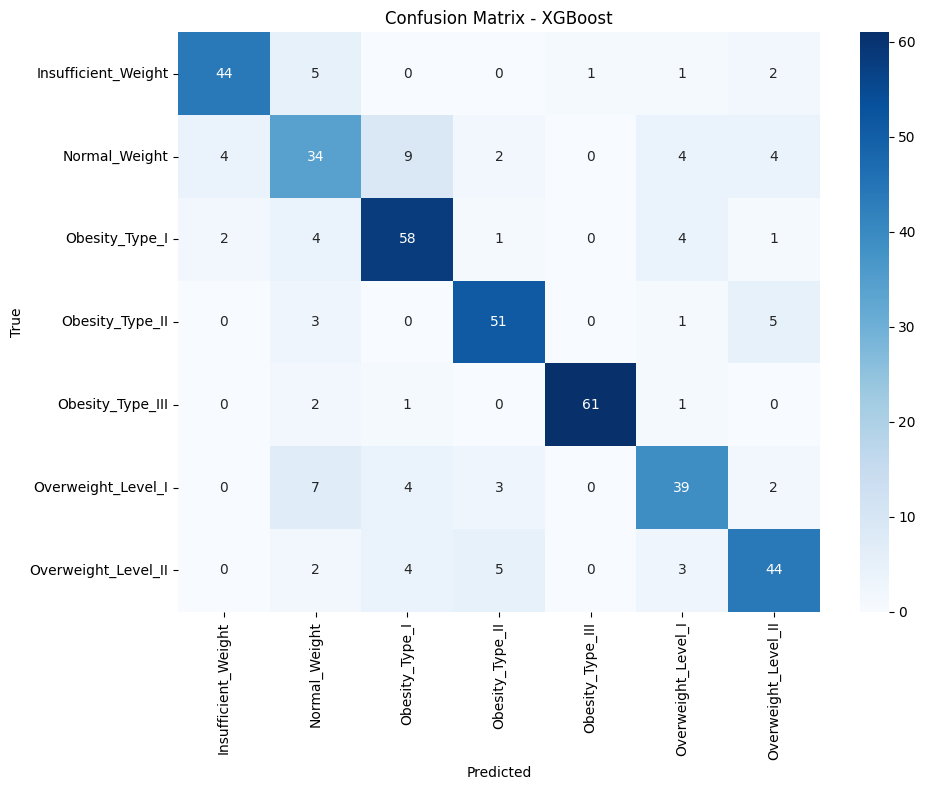


Classification Report (XGBoost):
                     precision    recall  f1-score   support

Insufficient_Weight       0.88      0.83      0.85        53
      Normal_Weight       0.60      0.60      0.60        57
     Obesity_Type_I       0.76      0.83      0.79        70
    Obesity_Type_II       0.82      0.85      0.84        60
   Obesity_Type_III       0.98      0.94      0.96        65
 Overweight_Level_I       0.74      0.71      0.72        55
Overweight_Level_II       0.76      0.76      0.76        58

           accuracy                           0.79       418
          macro avg       0.79      0.79      0.79       418
       weighted avg       0.79      0.79      0.79       418



In [21]:
from sklearn.metrics import confusion_matrix, classification_report

# 与 model_final 中混淆矩阵样式一致：Blues 色图
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - XGBoost')
plt.tight_layout()
plt.savefig('obesity_confusion_matrix.png', dpi=300)
plt.show()

print("\nClassification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb, target_names=list(le.classes_), zero_division=0))


Top 10 (transport 合并展示，各 dummy 列平均):
gender               0.143972
snacking             0.125306
veg_consumption      0.103878
high_cal_food        0.072900
alcohol              0.070411
calorie_monitor      0.063551
meals_per_day        0.057354
transport            0.056814
age                  0.053313
physical_activity    0.039532
dtype: float64


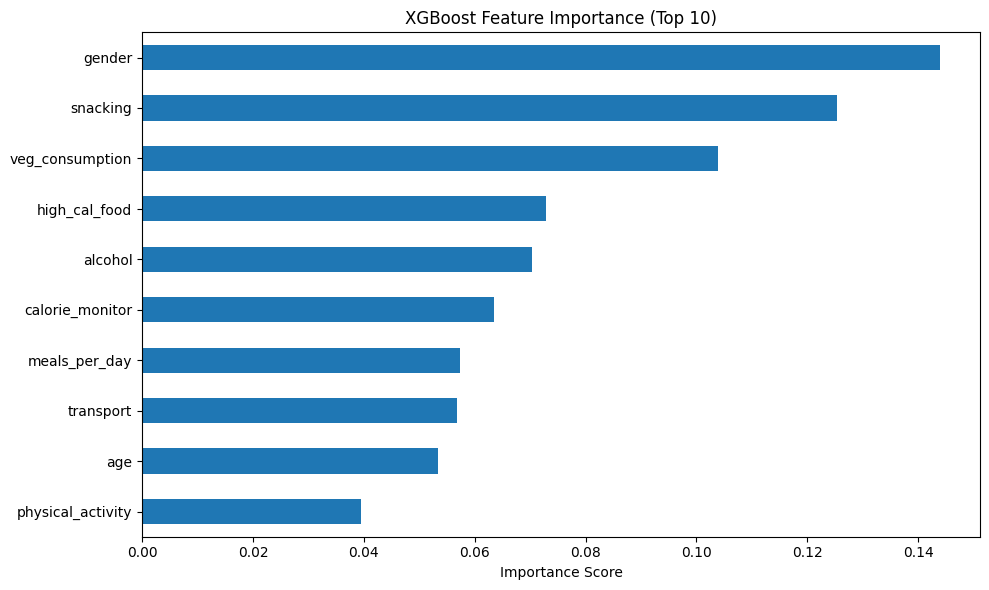

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from model_O import merge_transport_onehot_importance

# 获取特征重要性
importance = xgb.feature_importances_
feat_imp = pd.Series(importance, index=X_train.columns)

# 与 model_final 一致：画图前将 transport_* 合并为一项「transport」（各 dummy 列取平均）
feat_imp_plot = merge_transport_onehot_importance(feat_imp)
feat_imp_plot_sorted = feat_imp_plot.sort_values(ascending=False)

print("Top 10 (transport 合并展示，各 dummy 列平均):")
print(feat_imp_plot_sorted.head(10))
plt.figure(figsize=(10, 6))
feat_imp_plot_sorted.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('XGBoost Feature Importance (Top 10)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance_xgboost.png', dpi=300)
plt.show()
